In [1]:
import importlib
import util
importlib.reload(util)

<module 'util' from 'c:\\Users\\janav\\Documents\\load forecasting\\local-stlf\\forked-cnn-bi-lstm\\util.py'>

In [21]:
from util import convert_train_val, calculate_metrics, split_dataset
import time
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.preprocessing import MinMaxScaler
import numpy as np

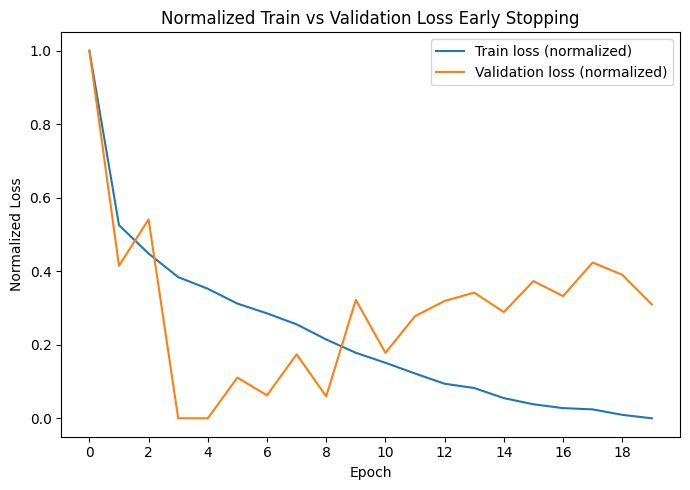

In [6]:
df = pd.read_csv('logs/training_log.csv')

df['val_loss'] = df['val_loss'].astype(float)
df['train_loss'] = df['train_loss'].astype(float)

# Min-max normalization
train_min = df['train_loss'].min()
train_max = df['train_loss'].max()
val_min = df['val_loss'].min()
val_max = df['val_loss'].max()

df['train_loss_norm'] = (df['train_loss'] - train_min) / (train_max - train_min)
df['val_loss_norm'] = (df['val_loss'] - val_min) / (val_max - val_min)

epochs = range(len(df))

plt.figure(figsize=(7, 5))
plt.plot(epochs, df['train_loss_norm'].values, label="Train loss (normalized)")
plt.plot(epochs, df['val_loss_norm'].values, label="Validation loss (normalized)")
plt.title("Normalized Train vs Validation Loss Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Normalized Loss")
plt.xticks(range(0, len(df), 2))  # ticks every 2 epochs
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# evaluate model fits model using training and validation data, then conducts a walk forwad validation with the test data
def evaluate_model_CNNBiLSTM(model, test, n_input, horizon, scaler):
	# history is a list of houry data
	# Convert test set into input-output sequences
	test_x, test_y = convert_train_val(test, n_input=n_input, n_out=horizon)
	# Predict in batch
	start_time = time.time()
	predictions = model.predict(test_x, verbose=0)
	end_time = time.time()
	# Ensure shape consistency
	if predictions.ndim == 3 and predictions.shape[-1] == 1:
		predictions = predictions[:, -1, :]
	actual = scaler.inverse_transform(test_y)
	predicted = scaler.inverse_transform(predictions)

	return actual, predicted, calculate_metrics(actual, predicted, end_time - start_time, 'st')

In [24]:
def horizon_rolling_forecast(model, initial_input, X_test, forecast_horizon, input_window, scaler):
    preds = []
    current_input = initial_input.copy()
    total_chunks = len(X_test) // forecast_horizon

    for i in range(total_chunks):
        print(f"🔮 Forecast chunk {i + 1}/{total_chunks}", end='\r', flush=True)

        # Predict next horizon values
        pred = model.predict(current_input, verbose=0)[0]  # shape: (horizon,)
        preds.extend(pred.tolist())

        # Get real input features for next horizon
        x_next_chunk = X_test[i * forecast_horizon: (i + 1) * forecast_horizon]

        # If 3D, take last timestep per horizon step
        if x_next_chunk.ndim == 3:
            x_next_chunk = x_next_chunk[:, -1, :]  # shape: (horizon, features)

        # Exclude target column (assumed to be first column)
        x_next_features = x_next_chunk[:, 1:]  # shape: (horizon, feature_dim - 1)

        # Combine predicted target + real features
        pred_array = np.array(pred).reshape(forecast_horizon, 1)  # shape: (horizon, 1)
        combined = np.concatenate([pred_array, x_next_features], axis=1)  # shape: (horizon, feature_dim)

        # Update current input window
        current_input = np.concatenate([
            current_input.reshape(-1, current_input.shape[-1]),  # shape: (input_window, feature_dim)
            combined
        ], axis=0)

        # Trim to keep only last `input_window` steps and reshape to model input shape
        current_input = current_input[-input_window:].reshape(1, input_window, -1)

    preds = np.array(preds).reshape(-1, 1)
    return scaler.inverse_transform(preds).flatten()

In [25]:
def plot_data(y_true, y_pred):
    plt.figure(figsize=(30, 7))
    plt.plot(y_true, color='blue', linewidth=0.5, label='True Values (t+1)')
    plt.plot(y_pred, color='red', linewidth=0.5, label='Predicted Values (t+1)')
    plt.title("Forecast Step t+1: Predicted vs True")
    plt.xlabel("Time Step")
    plt.ylabel("Rescaled Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [26]:
dataset = read_csv('data/data.csv', header=0, 
                infer_datetime_format=True, parse_dates=['datetime'], index_col=['datetime'])

n_input = 24 * 14
horizon = 1
batch_size = 64
# 1. Split raw dataset first (before scaling)
train, val, test = split_dataset(dataset, split_ratios=(0.6, 0.1, 0.3), daily_step=n_input, start=0)
train = train.to_numpy()
val = val.to_numpy()
test = test.to_numpy()

# 2. Flatten training set to fit scaler (reshape to 2D: [samples * timesteps, features])
train_2d = train.reshape(-1, train.shape[-1])
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_2d)
train = train_scaled.reshape(train.shape)

# 3. Scale val and test using the same scaler (transform only)
val = scaler.transform(val.reshape(-1, val.shape[-1])).reshape(val.shape)
test = scaler.transform(test.reshape(-1, test.shape[-1])).reshape(test.shape)


C:\Users\janav\AppData\Local\Temp\ipykernel_38932\105152004.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dataset = read_csv('data/data.csv', header=0,


In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam

model = load_model("models/model_epoch_20.h5", compile=False)
model.compile(loss=MeanSquaredError(), optimizer=Adam())


In [28]:
y_true, y_pred, results_st = evaluate_model_CNNBiLSTM(model, test, n_input, horizon, scaler)

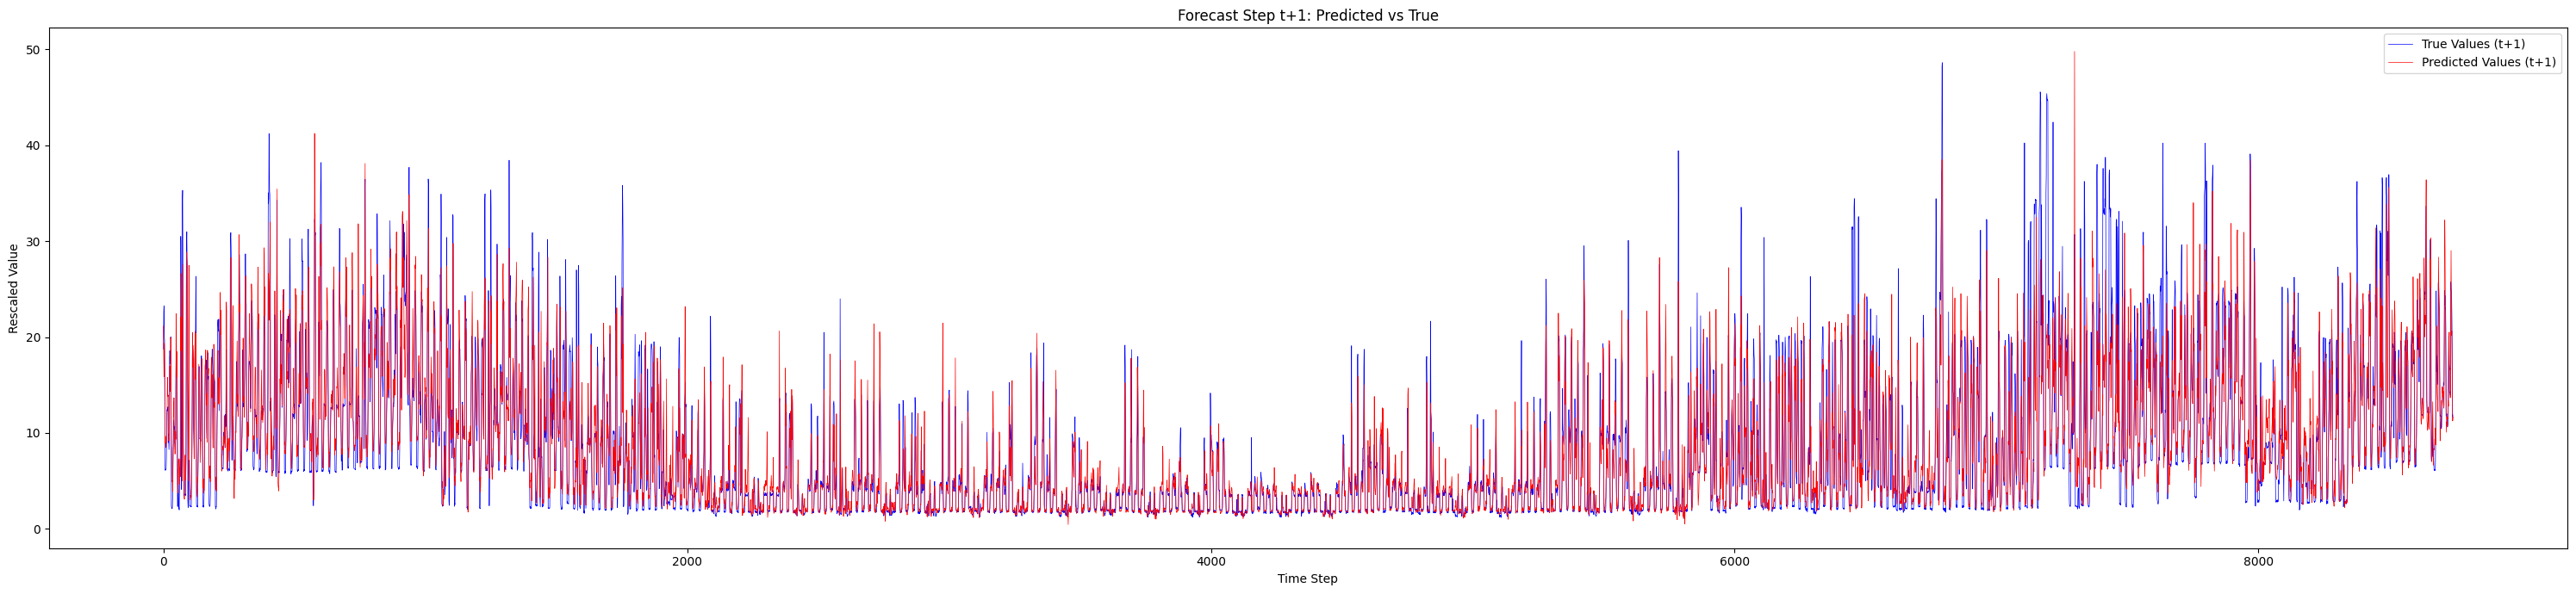

In [29]:
plot_data(y_true, y_pred)

In [30]:
X_val, _ = convert_train_val(val, n_input, horizon)
X_test, y_test = convert_train_val(test, n_input, horizon)

initial_input = X_val[-1:].copy()  # shape: (1, window, features)
true_rescaled = scaler.inverse_transform(y_test[:, :horizon])

start_time = time.time()
preds_rescaled = horizon_rolling_forecast(
    model=model,
    initial_input=initial_input,
    X_test=X_test,
    forecast_horizon=horizon,
    input_window=n_input,
    scaler=scaler
)
end_time = time.time()

y_auto = preds_rescaled.reshape(-1)
results_lt = calculate_metrics(y_true, y_auto, end_time-start_time, 'lt')

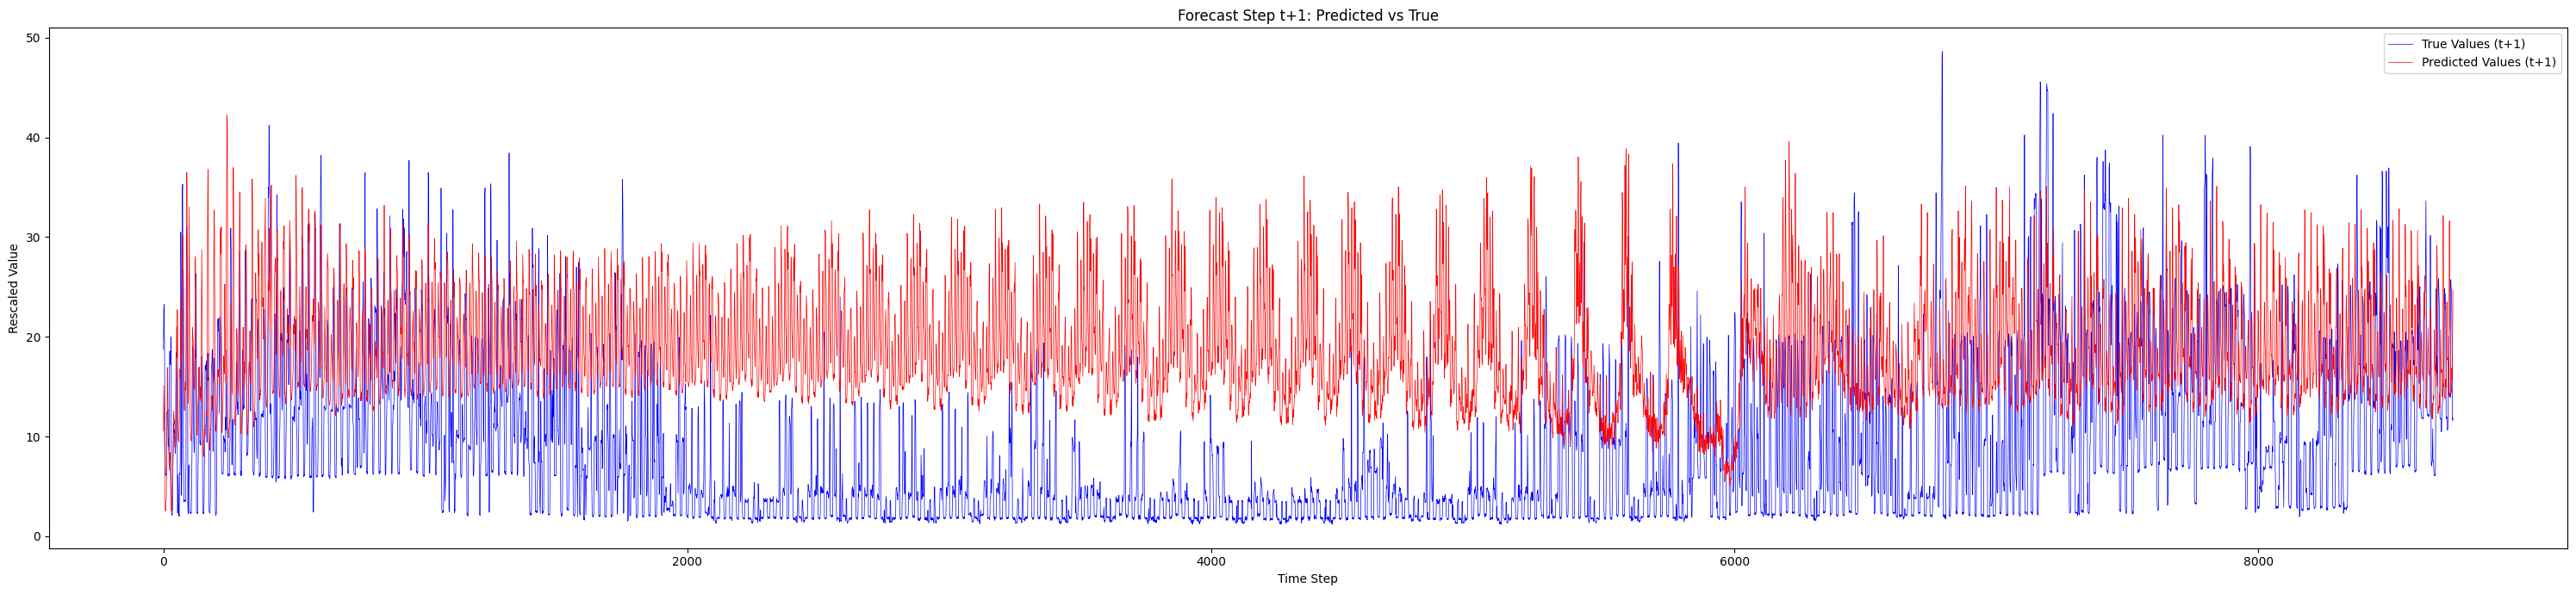

In [31]:
plot_data(y_true, y_auto)

In [32]:
results_df = pd.DataFrame([results_st, results_lt])

pred_df = pd.DataFrame({
    'y_true': y_true.flatten(),
    'y_st': y_pred.flatten(),
    'y_lt': y_auto.flatten()
})

results_df.to_csv('logs/prediction_eval.csv', index=False)
pred_df.to_csv('logs/prediction_data.csv', index=False)